# Tail diagnostics

Calibration diagnostics for the SAINT quantile forecasts, loaded from the compact NPZ artifact. The notebook produces the combined PIT/VaR/ES calibration figure first, followed by VaR exceedance counts.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Support running the notebook from either this project directory or the
# repository root.
evaluation_dir = Path.cwd()
if not (evaluation_dir / "tables" / "forecast_artifacts.py").is_file():
    evaluation_dir = evaluation_dir / "12. Evaluation of Probabilistic Forecasts"

sys.path.insert(0, str(evaluation_dir / "tables"))
from forecast_artifacts import load_forecast_artifact

model_path = (
    evaluation_dir
    / "model_logs"
    / "final_retrain_run"
    / "preds_test_set.compact.npz"
)
forecast = load_forecast_artifact(model_path)

true = np.asarray(forecast["true"], dtype=np.float64)
Q = np.asarray(forecast["Q"], dtype=np.float64)
u = np.asarray(forecast["u_grid"], dtype=np.float64)

if true.ndim != 2 or Q.ndim != 3 or Q.shape[:2] != true.shape:
    raise ValueError(f"Incompatible forecast shapes: true={true.shape}, Q={Q.shape}")
if u.ndim != 1 or Q.shape[-1] != u.size:
    raise ValueError(f"Incompatible quantile grid: Q={Q.shape}, u_grid={u.shape}")

# Enforce monotonicity against small numerical crossings in the quantile grid.
Q = np.maximum.accumulate(Q, axis=-1)

N, H = true.shape
horizons = np.arange(1, H + 1)
alphas = np.array([0.002, 0.005, 0.01, 0.02, 0.05])

# Block bootstrap settings; resampling keeps all horizons for each origin together.
n_boot = 1000
block_length = 24
random_seed = 1233

print(f"Loaded compact forecast: {model_path}")
print(f"true={true.shape}, Q={Q.shape}, quantile grid={u.shape}")


Loaded compact forecast: /home/jovyan/cloned_gits/onchain-insights/12. Evaluation of Probabilistic Forecasts/model_logs/final_retrain_run/preds_test_set.compact.npz
true=(11391, 24), Q=(11391, 24, 256), quantile grid=(256,)


In [2]:
def circular_block_indices(n, block_len, rng):
    """Circular moving-block bootstrap indices over forecast origins."""
    block_len = max(1, min(int(block_len), n))
    n_blocks = int(np.ceil(n / block_len))
    starts = rng.integers(0, n, size=n_blocks)
    indices = np.concatenate([
        (start + np.arange(block_len)) % n for start in starts
    ])
    return indices[:n]


def q_at(quantiles, quantile_grid, probability):
    """Interpolate a quantile forecast at one probability level."""
    probability = float(probability)
    if probability <= quantile_grid[0]:
        return quantiles[..., 0]
    if probability >= quantile_grid[-1]:
        return quantiles[..., -1]

    right = np.searchsorted(quantile_grid, probability)
    left = right - 1
    weight = (
        (probability - quantile_grid[left])
        / (quantile_grid[right] - quantile_grid[left])
    )
    return (1 - weight) * quantiles[..., left] + weight * quantiles[..., right]


def es_from_quantile_grid(quantiles, quantile_grid, alpha, side):
    """Integrate the forecast quantile function over a lower or upper tail."""
    quantiles_ext = np.concatenate(
        [quantiles[..., :1], quantiles, quantiles[..., -1:]], axis=-1
    )
    grid_ext = np.r_[0.0, quantile_grid, 1.0]

    if side == "lower":
        boundary = q_at(quantiles, quantile_grid, alpha)
        mask = grid_ext < alpha
        x = np.r_[grid_ext[mask], alpha]
        values = np.concatenate(
            [quantiles_ext[..., mask], boundary[..., None]], axis=-1
        )
    elif side == "upper":
        boundary = q_at(quantiles, quantile_grid, 1 - alpha)
        mask = grid_ext > 1 - alpha
        x = np.r_[1 - alpha, grid_ext[mask]]
        values = np.concatenate(
            [boundary[..., None], quantiles_ext[..., mask]], axis=-1
        )
    else:
        raise ValueError("side must be 'lower' or 'upper'")

    return np.trapezoid(values, x=x, axis=-1) / alpha


def pit_from_quantiles(observations, quantiles, quantile_grid):
    """Approximate the PIT by inverting each forecast quantile function."""
    n, h, n_quantiles = quantiles.shape
    pit = np.empty((n, h), dtype=np.float64)

    for horizon in range(h):
        qh = quantiles[:, horizon, :]
        yh = observations[:, horizon]
        idx = (qh <= yh[:, None]).sum(axis=1)
        left = np.clip(idx - 1, 0, n_quantiles - 2)
        right = left + 1

        q0 = qh[np.arange(n), left]
        q1 = qh[np.arange(n), right]
        u0 = quantile_grid[left]
        u1 = quantile_grid[right]
        weight = (yh - q0) / (q1 - q0 + 1e-12)
        pit[:, horizon] = np.clip(u0 + weight * (u1 - u0), 0, 1)

    return pit


def pit_ecdf(pit_values, grid):
    return np.searchsorted(np.sort(pit_values.ravel()), grid, side="right") / pit_values.size


def bootstrap_pit_ecdf(pit_values, grid, n_boot, block_len, seed):
    rng = np.random.default_rng(seed)
    point = pit_ecdf(pit_values, grid)
    bootstrap = np.empty((n_boot, grid.size))

    for b in range(n_boot):
        idx = circular_block_indices(pit_values.shape[0], block_len, rng)
        bootstrap[b] = pit_ecdf(pit_values[idx], grid)

    return (
        point,
        np.percentile(bootstrap, 2.5, axis=0),
        np.percentile(bootstrap, 97.5, axis=0),
    )


def tail_metrics(observations, hit, expected_shortfall, tail_levels):
    """Compute horizon-averaged coverage, ES, and exceedance-count summaries."""
    observations_3d = observations[:, :, None]
    hits_per_horizon = hit.sum(axis=0)

    realized_sum = (observations_3d * hit).sum(axis=0)
    predicted_sum = (expected_shortfall * hit).sum(axis=0)
    realized_by_horizon = np.full_like(realized_sum, np.nan, dtype=float)
    predicted_by_horizon = np.full_like(predicted_sum, np.nan, dtype=float)

    valid = hits_per_horizon > 0
    realized_by_horizon[valid] = realized_sum[valid] / hits_per_horizon[valid]
    predicted_by_horizon[valid] = predicted_sum[valid] / hits_per_horizon[valid]

    coverage_by_horizon = hit.mean(axis=0)
    return {
        "coverage": np.nanmean(coverage_by_horizon, axis=0),
        "realized_es": np.nanmean(realized_by_horizon, axis=0),
        "predicted_es": np.nanmean(predicted_by_horizon, axis=0),
        "mean_exceedance_count": np.mean(hits_per_horizon, axis=0),
    }


def bootstrap_tail_metrics(
    observations, var_forecast, es_forecast, tail_levels, side,
    n_boot, block_len, seed,
):
    if side == "lower":
        hit = observations[:, :, None] <= var_forecast
    elif side == "upper":
        hit = observations[:, :, None] >= var_forecast
    else:
        raise ValueError("side must be 'lower' or 'upper'")

    point = tail_metrics(observations, hit, es_forecast, tail_levels)
    rng = np.random.default_rng(seed)
    bootstrap = {
        key: np.empty((n_boot, len(tail_levels)))
        for key in point
    }

    for b in range(n_boot):
        idx = circular_block_indices(observations.shape[0], block_len, rng)
        sampled = tail_metrics(
            observations[idx], hit[idx], es_forecast[idx], tail_levels
        )
        for key in point:
            bootstrap[key][b] = sampled[key]

    result = {"point": point}
    for key, samples in bootstrap.items():
        result[f"{key}_lo"] = np.nanpercentile(samples, 2.5, axis=0)
        result[f"{key}_hi"] = np.nanpercentile(samples, 97.5, axis=0)
    return result


In [3]:
# PIT and its block-bootstrap confidence band.
pit = pit_from_quantiles(true, Q, u)
pit_grid = np.linspace(0, 1, 401)
pit_ecdf_point, pit_ecdf_low, pit_ecdf_high = bootstrap_pit_ecdf(
    pit, pit_grid, n_boot, block_length, random_seed
)

# VaR and ES forecasts for both tails.
var_lower = np.stack([q_at(Q, u, alpha) for alpha in alphas], axis=-1)
var_upper = np.stack([q_at(Q, u, 1 - alpha) for alpha in alphas], axis=-1)
es_lower = np.stack([
    es_from_quantile_grid(Q, u, alpha, side="lower") for alpha in alphas
], axis=-1)
es_upper = np.stack([
    es_from_quantile_grid(Q, u, alpha, side="upper") for alpha in alphas
], axis=-1)

bootstrap_lower = bootstrap_tail_metrics(
    true, var_lower, es_lower, alphas, "lower",
    n_boot, block_length, random_seed + 1,
)
bootstrap_upper = bootstrap_tail_metrics(
    true, var_upper, es_upper, alphas, "upper",
    n_boot, block_length, random_seed + 2,
)

pit_ks = stats.kstest(pit.ravel(), "uniform")
print(
    f"PIT mean={pit.mean():.4f}; variance={pit.var():.4f} "
    f"(uniform target: {1 / 12:.4f}); KS p-value={pit_ks.pvalue:.4g}"
)


PIT mean=0.5022; variance=0.0878 (uniform target: 0.0833); KS p-value=4.636e-198


## PIT, VaR, and ES calibration

The first figure combines the horizon-pooled PIT ECDF, lower/upper VaR exceedance calibration, and realized versus forecast ES.

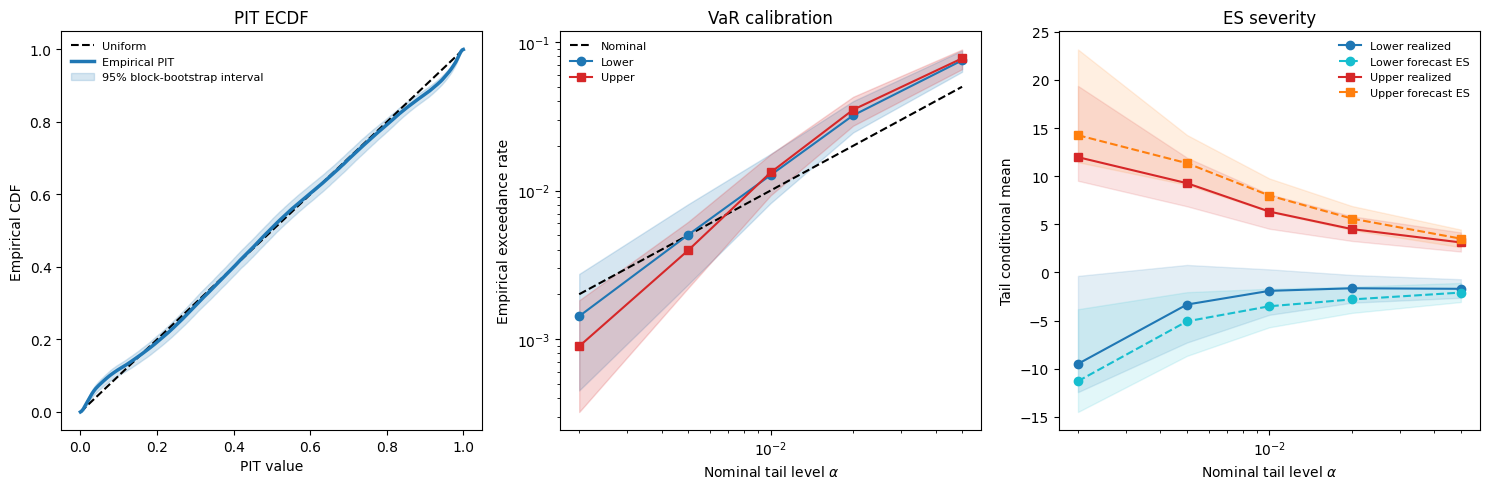

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# PIT ECDF
axes[0].plot(pit_grid, pit_grid, "k--", lw=1.5, label="Uniform")
axes[0].plot(
    pit_grid, pit_ecdf_point, color="tab:blue", lw=2.5, label="Empirical PIT"
)
axes[0].fill_between(
    pit_grid, pit_ecdf_low, pit_ecdf_high, color="tab:blue", alpha=0.18,
    label="95% block-bootstrap interval",
)
axes[0].set(xlabel="PIT value", ylabel="Empirical CDF", title="PIT ECDF")
axes[0].legend(frameon=False, fontsize=8)

# VaR exceedance calibration
axes[1].plot(alphas, alphas, "k--", label="Nominal")
for side, result, marker, color, label in [
    ("lower", bootstrap_lower, "o", "tab:blue", "Lower"),
    ("upper", bootstrap_upper, "s", "tab:red", "Upper"),
]:
    axes[1].plot(
        alphas, result["point"]["coverage"], marker + "-", color=color, label=label
    )
    axes[1].fill_between(
        alphas, result["coverage_lo"], result["coverage_hi"],
        color=color, alpha=0.18,
    )
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set(
    xlabel=r"Nominal tail level $\alpha$",
    ylabel="Empirical exceedance rate",
    title="VaR calibration",
)
axes[1].legend(frameon=False, fontsize=8)

# ES severity, conditional on a VaR exceedance
for result, marker, color, pred_color, label in [
    (bootstrap_lower, "o", "tab:blue", "tab:cyan", "Lower"),
    (bootstrap_upper, "s", "tab:red", "tab:orange", "Upper"),
]:
    for key, line_style, series_label, series_color in [
        ("realized_es", "-", "realized", color),
        ("predicted_es", "--", "forecast ES", pred_color),
    ]:
        point = result["point"][key]
        axes[2].plot(
            alphas, point, marker + line_style, color=series_color,
            label=f"{label} {series_label}",
        )
        axes[2].fill_between(
            alphas, result[f"{key}_lo"], result[f"{key}_hi"],
            color=series_color, alpha=0.12,
        )
axes[2].set_xscale("log")
axes[2].set(
    xlabel=r"Nominal tail level $\alpha$",
    ylabel="Tail conditional mean",
    title="ES severity",
)
axes[2].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(
    "PIT_VAR_ES_calibration.png", dpi=300, transparent=True, bbox_inches="tight"
)
plt.show()


## VaR exceedance counts

Mean exceedance counts per forecast horizon, with moving-block bootstrap intervals and nominal expected counts.

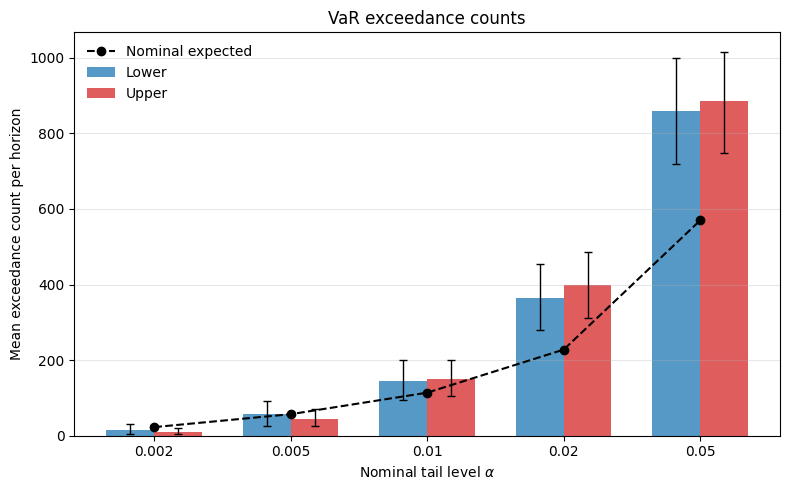

In [7]:
x = np.arange(alphas.size)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))

for result, offset, color, label in [
    (bootstrap_lower, -width / 2, "tab:blue", "Lower"),
    (bootstrap_upper, width / 2, "tab:red", "Upper"),
]:
    point = result["point"]["mean_exceedance_count"]
    lower = result["mean_exceedance_count_lo"]
    upper = result["mean_exceedance_count_hi"]
    yerr = np.vstack([np.maximum(point - lower, 0), np.maximum(upper - point, 0)])

    ax.bar(x + offset, point, width, color=color, alpha=0.75, label=label)
    ax.errorbar(
        x + offset, point, yerr=yerr, fmt="none", ecolor="black",
        capsize=3, lw=1,
    )

ax.plot(x, N * alphas, "k--o", label="Nominal expected")
ax.set_xticks(x)
ax.set_xticklabels([f"{alpha:g}" for alpha in alphas])
ax.set(
    xlabel=r"Nominal tail level $\alpha$",
    ylabel="Mean exceedance count per horizon",
    title="VaR exceedance counts",
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig('var_exceedance_counts.png', dpi = 300, transparent=True)
plt.show()
